In [ ]:
# =============================================================================
# IMPORTS
# =============================================================================
import os
import glob
import random
import warnings
import json
from collections import defaultdict

import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

from IPython.display import Audio, display

warnings.filterwarnings('ignore')

# =============================================================================
# REPRODUCIBILITY SETTINGS
# =============================================================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# =============================================================================
# CONFIGURATION PARAMETERS
# =============================================================================
DATASET_DIR = "D:/Skripsi/content/DATASET/CREMA"  # Adjust to your dataset location

# Audio processing parameters
SAMPLE_RATE = 16000      # 16 kHz - standard for speech
DURATION = 3.0           # Fixed duration in seconds
N_MELS = 128             # Mel frequency bins
N_FFT = 512              # FFT window size
HOP_LENGTH = 256         # Hop length for STFT

# Target emotion classes
TARGET_EMOTIONS = ["angry", "happy", "sad", "neutral"]

# Training parameters
BATCH_SIZE = 32
EPOCHS = 60

# Derived parameters
EXPECTED_FRAMES = int(np.ceil(DURATION * SAMPLE_RATE / HOP_LENGTH))

# Output directories
OUTPUT_DIR = "outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
AUDIO_DIR = os.path.join(OUTPUT_DIR, "audio_examples")
EVALUATION_DIR = os.path.join(OUTPUT_DIR, "evaluation")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")

for d in [FIGURES_DIR, AUDIO_DIR, EVALUATION_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print("=" * 60)
print("CONFIGURATION SUMMARY")
print("=" * 60)
print(f"Sample Rate:      {SAMPLE_RATE} Hz")
print(f"Duration:         {DURATION} seconds")
print(f"Mel Bins:         {N_MELS}")
print(f"FFT Size:         {N_FFT}")
print(f"Hop Length:       {HOP_LENGTH}")
print(f"Expected Frames:  {EXPECTED_FRAMES}")
print(f"Target Emotions:  {TARGET_EMOTIONS}")
print(f"Batch Size:       {BATCH_SIZE}")
print(f"Max Epochs:       {EPOCHS}")
print(f"Random Seed:      {SEED}")
print("=" * 60)

CONFIGURATION SUMMARY
Sample Rate:      16000 Hz
Duration:         3.0 seconds
Mel Bins:         128
FFT Size:         512
Hop Length:       256
Expected Frames:  188
Target Emotions:  ['angry', 'happy', 'sad', 'neutral']
Batch Size:       32
Max Epochs:       60
Random Seed:      42


In [7]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
from collections import Counter
warnings.filterwarnings('ignore')

# =====================================================
# LOAD & PERBAIKI PATH
# =====================================================
berkas_csv = "D:/Skripsi/Penelitian/NEW GOLD MODEL/outputs/evaluation/ensemble_predictions.csv"
df_prediksi = pd.read_csv(berkas_csv)

FOLDER_DATASET = "D:/dfdfd/content/DATASET/CREMA/"
df_prediksi['file'] = df_prediksi['file'].apply(
    lambda x: FOLDER_DATASET + os.path.basename(x)
)

df_benar = df_prediksi[df_prediksi['true'] == df_prediksi['pred']].copy()
df_salah = df_prediksi[df_prediksi['true'] != df_prediksi['pred']].copy()

# Verifikasi sebelum lanjut
print("Cek path df_benar:", df_benar['file'].iloc[0])
print("Ada?:", os.path.exists(df_benar['file'].iloc[0]))

Cek path df_benar: D:/dfdfd/content/DATASET/CREMA/1002_DFA_HAP_XX.wav
Ada?: True


In [8]:
label_to_idx = {e: i for i, e in enumerate(TARGET_EMOTIONS)}
idx_to_label = {i: e for e, i in label_to_idx.items()}

In [9]:
import pandas as pd
csv_path = os.path.join(EVALUATION_DIR, "ensemble_predictions.csv")

if os.path.exists(csv_path):
    print("✅ CSV ditemukan, langsung lanjut ke analisis.")
else:
    print("❌ CSV belum ada. Jalankan Cell 23 di notebook lama dulu.")

✅ CSV ditemukan, langsung lanjut ke analisis.


  ANALISIS SAMPEL PREDIKSI PER EMOSI
  Total sampel uji : 809
  Prediksi benar   : 661 (81.7%)
  Prediksi salah   : 148 (18.3%)

  Mengekstrak ciri akustik untuk emosi 'angry'...


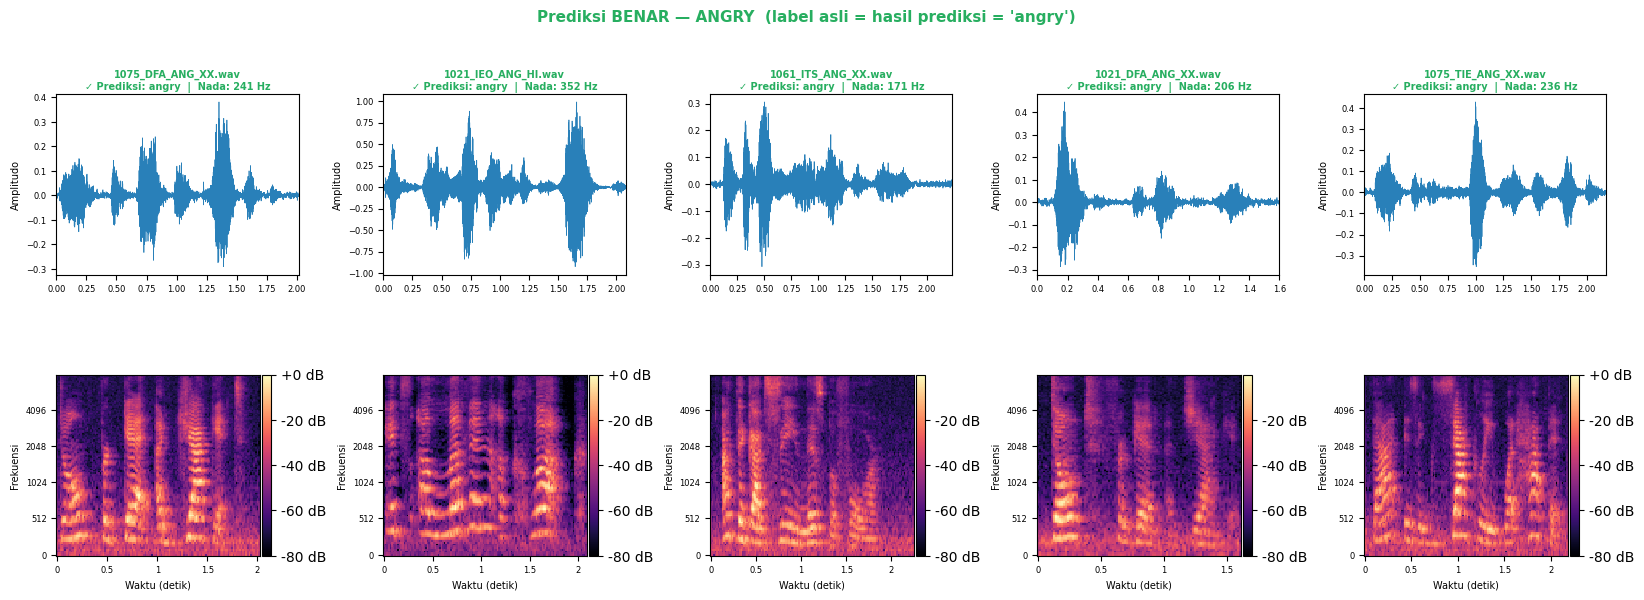

  Gambar benar tersimpan → outputs\figures\benar_angry.png


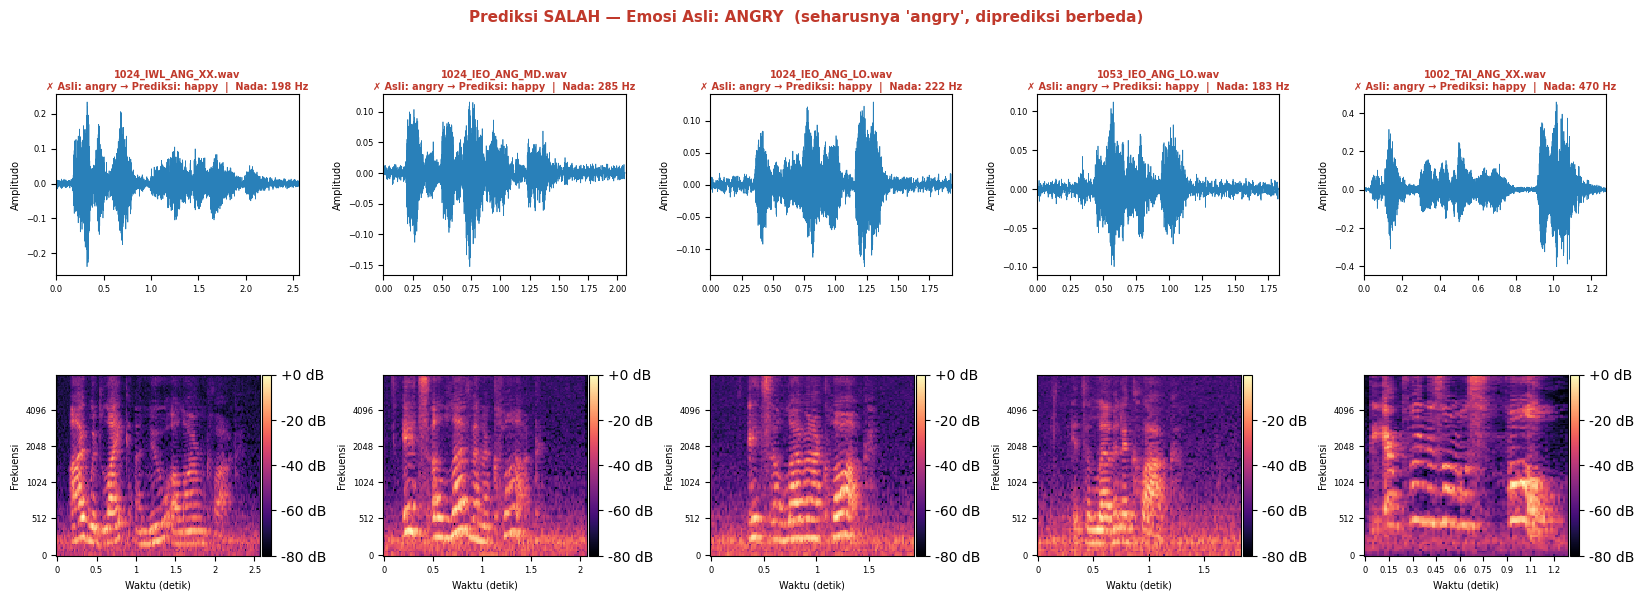

  Gambar salah tersimpan → outputs\figures\salah_angry.png
  ANALISIS EMOSI: ANGRY

[Karakteristik Umum Emosi Ini]
  Emosi marah secara akustik ditandai dengan nada suara yang
  tinggi, intensitas yang keras, laju bicara yang cepat, serta
  fluktuasi nada yang besar. Pola ini mencerminkan ketegangan fisik
  dan emosional yang kuat pada saat marah.

[Perbandingan Rata-rata Ciri Akustik]
  Ciri Akustik                             Benar      Salah
  ----------------------------------- ---------- ----------
  Nada Rata-rata (Hz)                   241.0 Hz   271.5 Hz
  Variasi Nada (Hz)                      49.1 Hz    43.8 Hz
  Intensitas Suara                       0.04420    0.02468
  Laju Bicara (ketukan/menit)          122.6 bpm  137.4 bpm
  Kecerahan Suara (Hz)                 1703.7 Hz  1569.6 Hz
  Rasio Segmen Bersuara                     0.82       0.70

[Analisis: Mengapa Prediksi Benar?]
  Sampel yang berhasil diprediksi dengan benar pada emosi angry
  umumnya memiliki rata-rata n

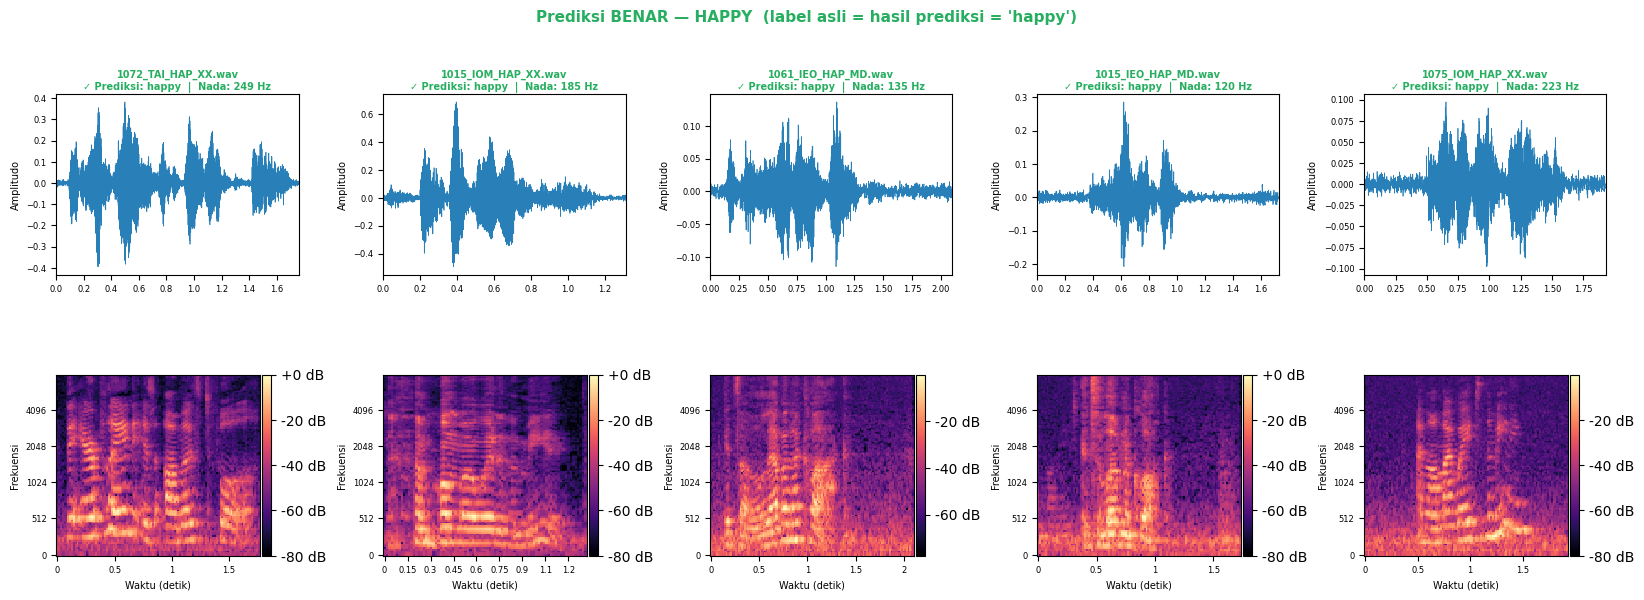

  Gambar benar tersimpan → outputs\figures\benar_happy.png


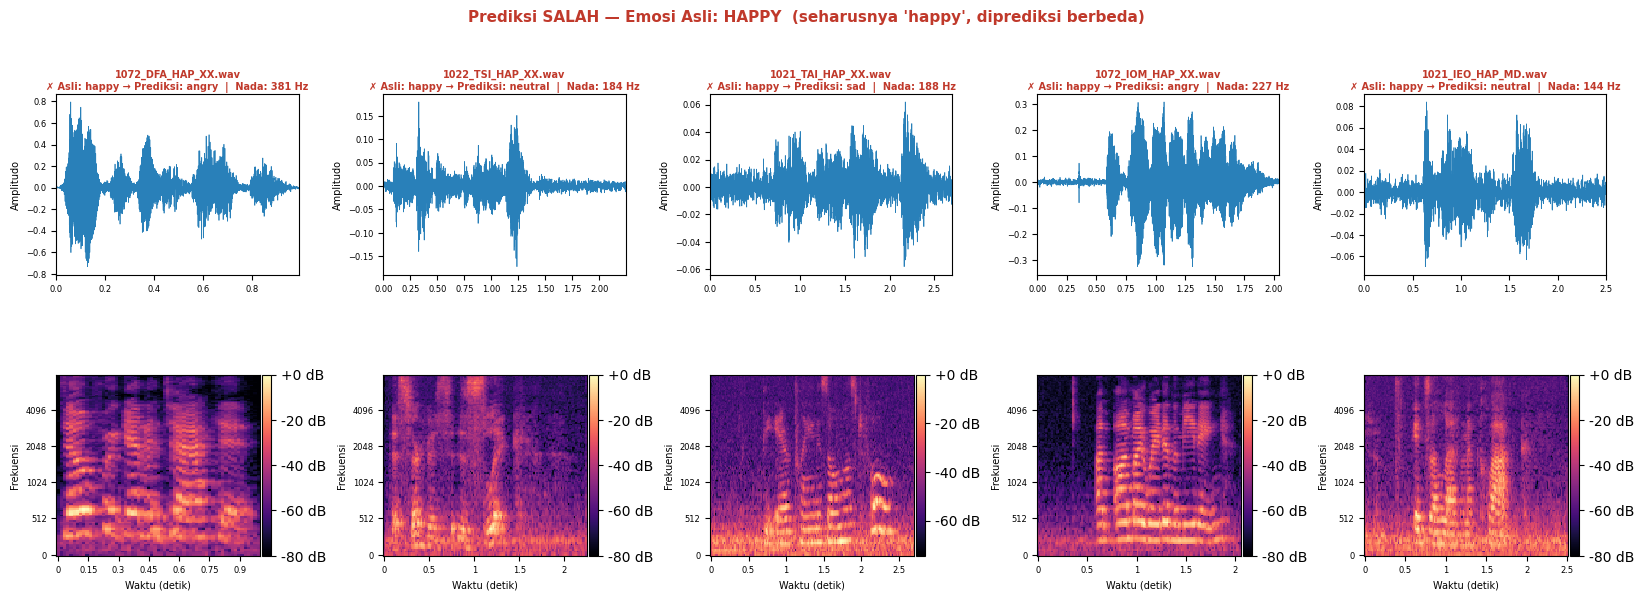

  Gambar salah tersimpan → outputs\figures\salah_happy.png
  ANALISIS EMOSI: HAPPY

[Karakteristik Umum Emosi Ini]
  Emosi bahagia ditandai dengan nada suara yang variatif dan
  cenderung tinggi, laju bicara yang cepat, serta kandungan
  frekuensi tinggi yang lebih banyak. Pola ini mencerminkan
  semangat dan antusiasme dalam pengucapan.

[Perbandingan Rata-rata Ciri Akustik]
  Ciri Akustik                             Benar      Salah
  ----------------------------------- ---------- ----------
  Nada Rata-rata (Hz)                   182.4 Hz   224.9 Hz
  Variasi Nada (Hz)                      49.0 Hz    59.5 Hz
  Intensitas Suara                       0.03476    0.03913
  Laju Bicara (ketukan/menit)          141.3 bpm  131.8 bpm
  Kecerahan Suara (Hz)                 1395.7 Hz  1547.2 Hz
  Rasio Segmen Bersuara                     0.68       0.68

[Analisis: Mengapa Prediksi Benar?]
  Sampel yang berhasil diprediksi dengan benar pada emosi happy
  umumnya memiliki nada suara yang cukup

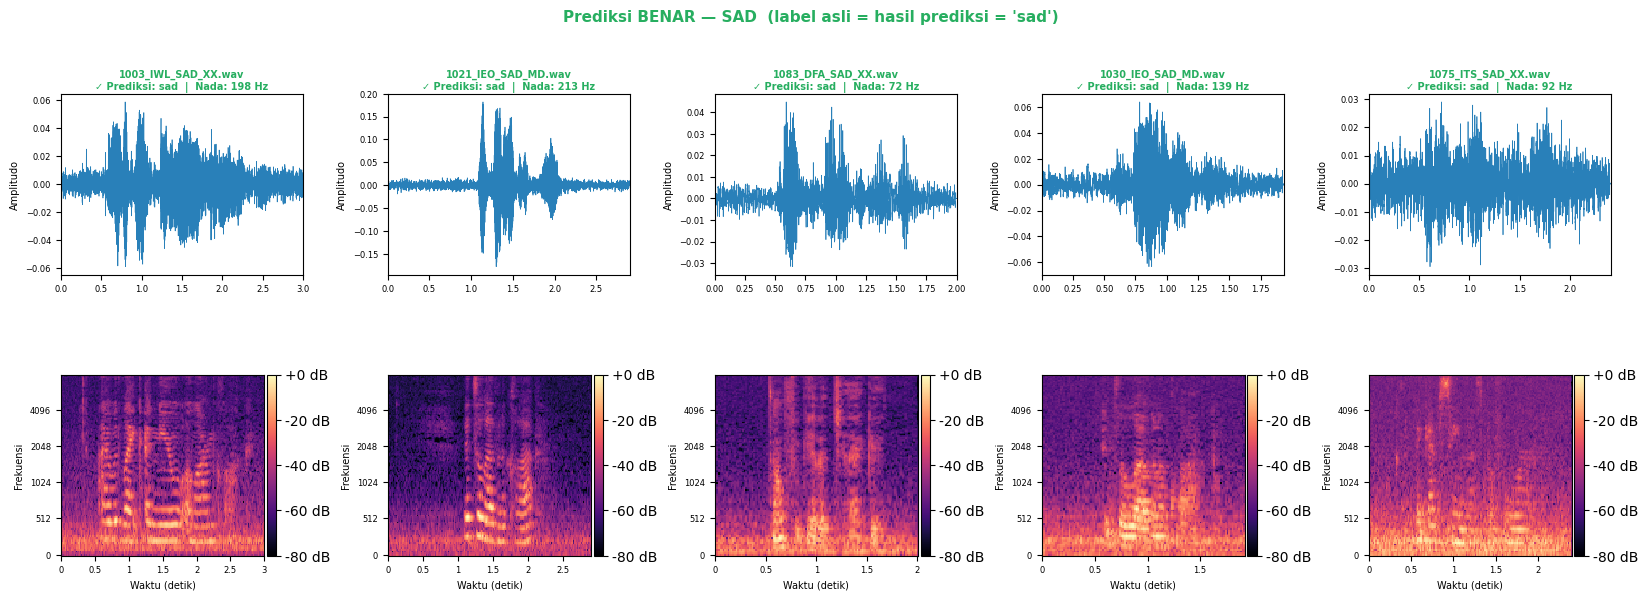

  Gambar benar tersimpan → outputs\figures\benar_sad.png


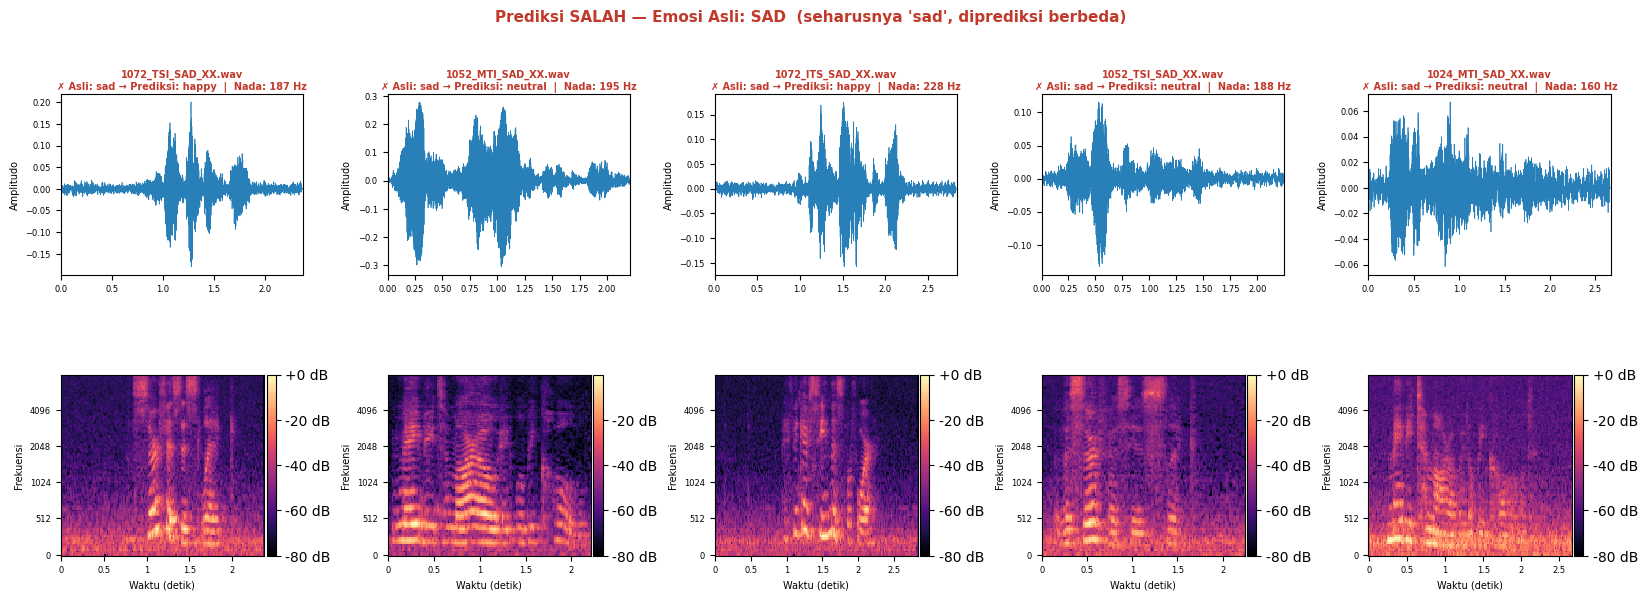

  Gambar salah tersimpan → outputs\figures\salah_sad.png
  ANALISIS EMOSI: SAD

[Karakteristik Umum Emosi Ini]
  Emosi sedih ditandai dengan nada suara yang rendah dan monoton,
  intensitas yang lemah, serta laju bicara yang lambat. Pola ini
  mencerminkan kondisi lesu dan kurangnya energi pada saat sedih.

[Perbandingan Rata-rata Ciri Akustik]
  Ciri Akustik                             Benar      Salah
  ----------------------------------- ---------- ----------
  Nada Rata-rata (Hz)                   142.6 Hz   191.4 Hz
  Variasi Nada (Hz)                      25.8 Hz    60.0 Hz
  Intensitas Suara                       0.00899    0.01981
  Laju Bicara (ketukan/menit)          129.0 bpm  121.0 bpm
  Kecerahan Suara (Hz)                 1387.2 Hz  1496.5 Hz
  Rasio Segmen Bersuara                     0.48       0.62

[Analisis: Mengapa Prediksi Benar?]
  Sampel yang berhasil diprediksi dengan benar pada emosi sad
  umumnya memiliki nada suara yang rendah (143 Hz) yang sesuai
  dengan pr

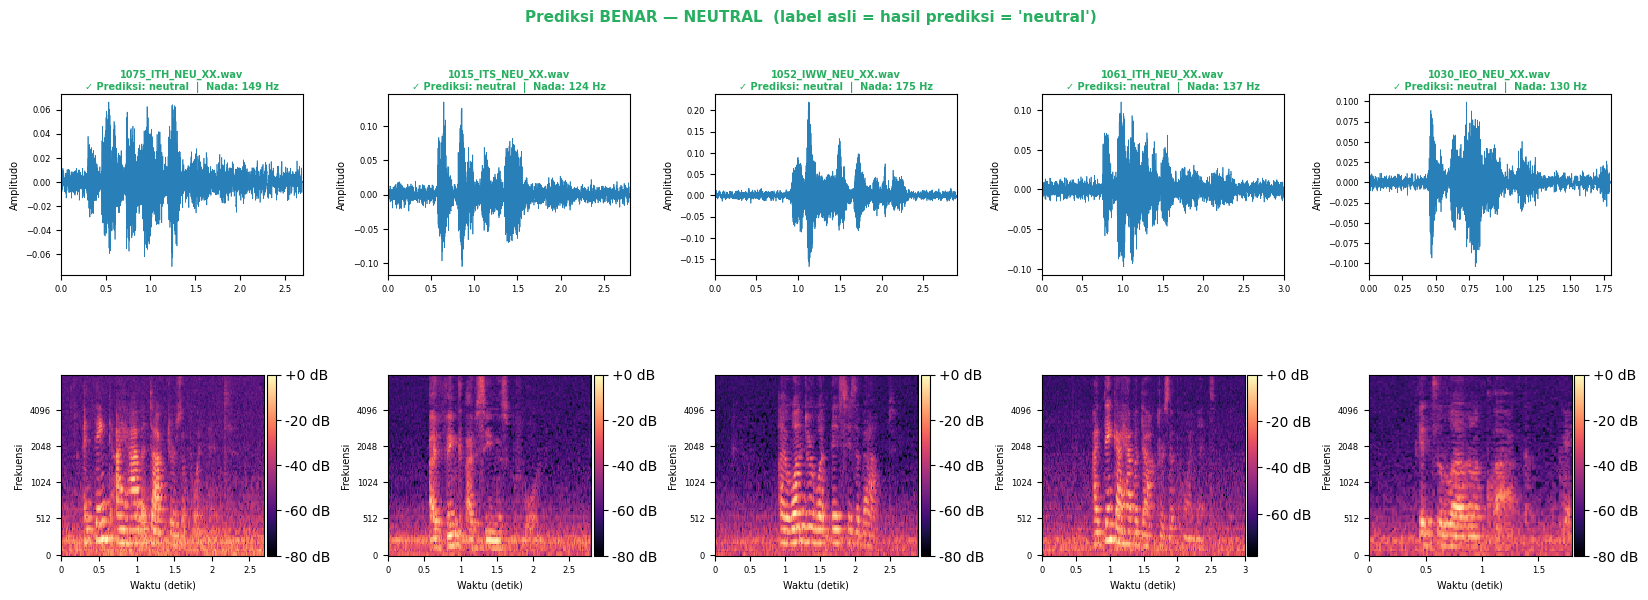

  Gambar benar tersimpan → outputs\figures\benar_neutral.png


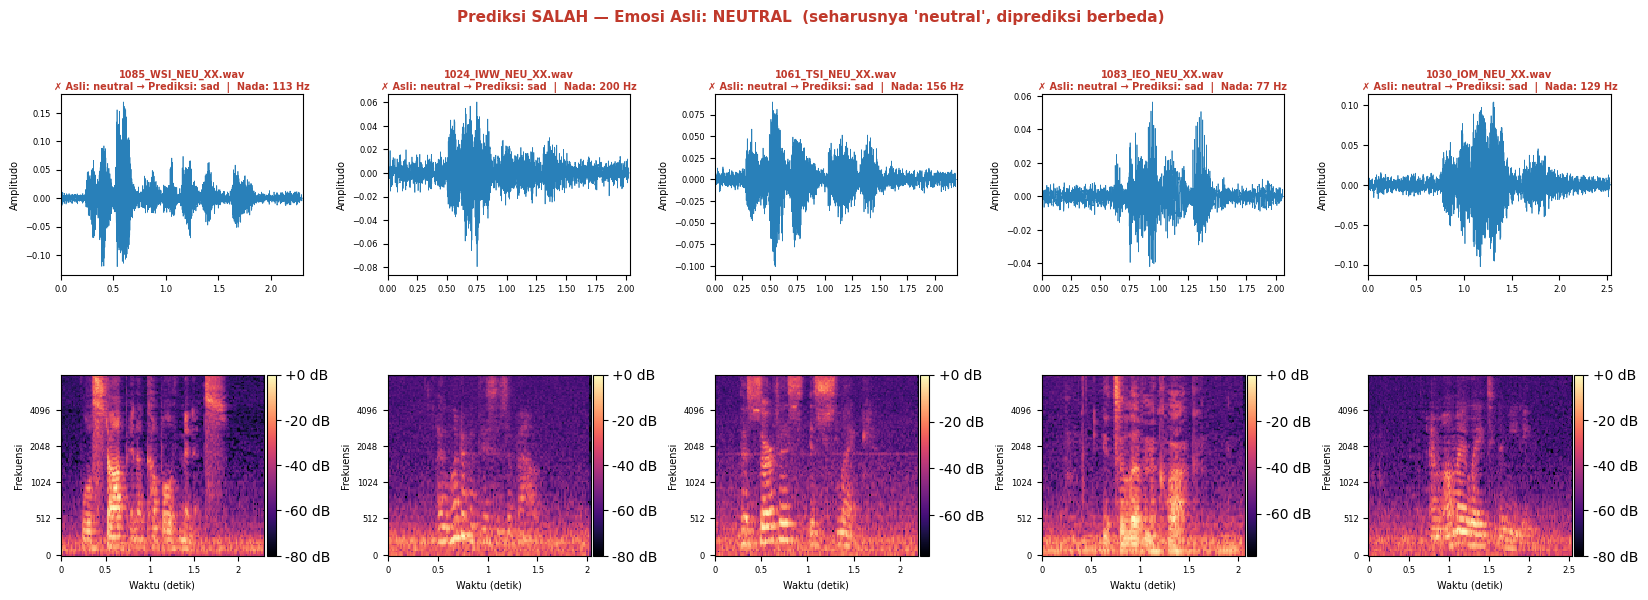

  Gambar salah tersimpan → outputs\figures\salah_neutral.png
  ANALISIS EMOSI: NEUTRAL

[Karakteristik Umum Emosi Ini]
  Emosi netral ditandai dengan nada suara yang stabil pada kisaran
  sedang, intensitas yang terkontrol, dan laju bicara yang normal.
  Tidak ada fluktuasi ekstrem yang mencirikan emosi tertentu.

[Perbandingan Rata-rata Ciri Akustik]
  Ciri Akustik                             Benar      Salah
  ----------------------------------- ---------- ----------
  Nada Rata-rata (Hz)                   143.3 Hz   134.9 Hz
  Variasi Nada (Hz)                      31.0 Hz    27.7 Hz
  Intensitas Suara                       0.01192    0.01016
  Laju Bicara (ketukan/menit)          146.8 bpm  108.7 bpm
  Kecerahan Suara (Hz)                 1333.7 Hz  1619.4 Hz
  Rasio Segmen Bersuara                     0.58       0.75

[Analisis: Mengapa Prediksi Benar?]
  Sampel yang berhasil diprediksi dengan benar pada emosi neutral
  umumnya memiliki nada suara pada kisaran sedang (143 Hz) yang

In [10]:
# =============================================================================
# ANALISIS SAMPEL BENAR & SALAH PER EMOSI
# Untuk Laporan Skripsi - Speech Emotion Recognition
#
# CARA PAKAI:
#   Copy semua kode ini → paste ke cell baru paling bawah di notebook
#   SER_Thesis_Final__Ensemble_.ipynb → lalu jalankan.
#
#   Syarat: Cell 23 (evaluasi ensemble) sudah dijalankan terlebih dahulu
#   sehingga file ensemble_predictions.csv sudah tersedia.
#
# OUTPUT:
#   - 8 gambar PNG (gelombang suara + mel-spektrogram, benar & salah per emosi)
#   - Narasi analisis dicetak langsung di notebook
# =============================================================================

# =============================================================================
# KONFIGURASI
# =============================================================================
JUMLAH_SAMPEL = 5            # Jumlah sampel per emosi per kategori
FOLDER_GAMBAR = FIGURES_DIR  # Menggunakan folder dari notebook

# Profil akustik ideal tiap emosi berdasarkan literatur
PROFIL_EMOSI = {
    'angry': {
        'deskripsi': (
            "Emosi marah secara akustik ditandai dengan nada suara yang tinggi, "
            "intensitas yang keras, laju bicara yang cepat, serta fluktuasi nada "
            "yang besar. Pola ini mencerminkan ketegangan fisik dan emosional "
            "yang kuat pada saat marah."
        ),
    },
    'happy': {
        'deskripsi': (
            "Emosi bahagia ditandai dengan nada suara yang variatif dan cenderung "
            "tinggi, laju bicara yang cepat, serta kandungan frekuensi tinggi yang "
            "lebih banyak. Pola ini mencerminkan semangat dan antusiasme dalam "
            "pengucapan."
        ),
    },
    'sad': {
        'deskripsi': (
            "Emosi sedih ditandai dengan nada suara yang rendah dan monoton, "
            "intensitas yang lemah, serta laju bicara yang lambat. Pola ini "
            "mencerminkan kondisi lesu dan kurangnya energi pada saat sedih."
        ),
    },
    'neutral': {
        'deskripsi': (
            "Emosi netral ditandai dengan nada suara yang stabil pada kisaran "
            "sedang, intensitas yang terkontrol, dan laju bicara yang normal. "
            "Tidak ada fluktuasi ekstrem yang mencirikan emosi tertentu."
        ),
    },
}

NAMA_FITUR = {
    'nada_rata':      'Nada Rata-rata (Hz)',
    'variasi_nada':   'Variasi Nada (Hz)',
    'intensitas':     'Intensitas Suara',
    'laju_bicara':    'Laju Bicara (ketukan/menit)',
    'kecerahan':      'Kecerahan Suara (Hz)',
    'rasio_bersuara': 'Rasio Segmen Bersuara',
}


# =============================================================================
# FUNGSI 1: EKSTRAKSI CIRI AKUSTIK
# =============================================================================
def ekstrak_ciri(filepath):
    """Ekstrak ciri akustik dari satu file audio."""
    try:
        y, _ = librosa.load(filepath, sr=SAMPLE_RATE, duration=DURATION)
        y, _ = librosa.effects.trim(y, top_db=25)

        # Nada (F0) menggunakan pyin
        f0, tanda_bersuara, _ = librosa.pyin(
            y,
            fmin=librosa.note_to_hz('C2'),
            fmax=librosa.note_to_hz('C7'),
            sr=SAMPLE_RATE
        )
        f0_bersuara  = f0[tanda_bersuara] if tanda_bersuara is not None else np.array([])
        nada_rata    = float(np.nanmean(f0_bersuara)) if len(f0_bersuara) > 0 else 0.0
        variasi_nada = float(np.nanstd(f0_bersuara))  if len(f0_bersuara) > 0 else 0.0

        # Intensitas (RMS)
        rms        = librosa.feature.rms(y=y)[0]
        intensitas = float(np.mean(rms))

        # Laju bicara (tempo)
        onset_env   = librosa.onset.onset_strength(y=y, sr=SAMPLE_RATE)
        tempo, _    = librosa.beat.beat_track(onset_envelope=onset_env, sr=SAMPLE_RATE)
        laju_bicara = float(tempo) if not np.isnan(float(tempo)) else 0.0

        # Kecerahan suara (spectral centroid)
        sc        = librosa.feature.spectral_centroid(y=y, sr=SAMPLE_RATE)[0]
        kecerahan = float(np.mean(sc))

        # Rasio segmen bersuara
        rasio = (float(np.sum(tanda_bersuara)) / len(tanda_bersuara)
                 if tanda_bersuara is not None and len(tanda_bersuara) > 0
                 else 0.0)

        return {
            'nada_rata':      round(nada_rata, 2),
            'variasi_nada':   round(variasi_nada, 2),
            'intensitas':     round(intensitas, 5),
            'laju_bicara':    round(laju_bicara, 2),
            'kecerahan':      round(kecerahan, 2),
            'rasio_bersuara': round(rasio, 3),
        }
    except Exception:
        return {k: 0.0 for k in NAMA_FITUR}


# =============================================================================
# FUNGSI 2: PLOT PANEL AUDIO
# =============================================================================
def plot_panel(ax_gelombang, ax_spektro, filepath, label_benar, label_prediksi, ciri):
    """Plot gelombang suara dan mel-spektrogram pada sumbu yang diberikan."""
    tepat = (label_benar == label_prediksi)
    warna = '#27ae60' if tepat else '#c0392b'
    try:
        y, sr = librosa.load(filepath, sr=SAMPLE_RATE, duration=DURATION)
        y, _  = librosa.effects.trim(y, top_db=25)
        waktu = np.linspace(0, len(y) / sr, len(y))

        # Gelombang suara
        ax_gelombang.plot(waktu, y, color='#2980b9', linewidth=0.5)
        ax_gelombang.set_ylabel("Amplitudo", fontsize=7)
        ax_gelombang.tick_params(labelsize=6)
        ax_gelombang.set_xlim([0, waktu[-1]])

        nama_file = os.path.basename(filepath)
        if tepat:
            judul = (f"{nama_file}\n"
                     f"✓ Prediksi: {label_prediksi}  |  "
                     f"Nada: {ciri['nada_rata']:.0f} Hz")
        else:
            judul = (f"{nama_file}\n"
                     f"✗ Asli: {label_benar} → Prediksi: {label_prediksi}  |  "
                     f"Nada: {ciri['nada_rata']:.0f} Hz")
        ax_gelombang.set_title(judul, fontsize=7, fontweight='bold',
                                color=warna, pad=3)

        # Mel-spektrogram
        S    = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
        S_db = librosa.power_to_db(S, ref=np.max)
        gambar = librosa.display.specshow(
            S_db, sr=sr, hop_length=HOP_LENGTH,
            x_axis='time', y_axis='mel',
            ax=ax_spektro, cmap='magma')
        ax_spektro.set_xlabel("Waktu (detik)", fontsize=7)
        ax_spektro.set_ylabel("Frekuensi", fontsize=7)
        ax_spektro.tick_params(labelsize=6)
        plt.colorbar(gambar, ax=ax_spektro, format='%+2.0f dB', pad=0.01)

    except Exception as e:
        ax_gelombang.text(0.5, 0.5, f"Gagal memuat file:\n{e}",
                           ha='center', va='center',
                           transform=ax_gelombang.transAxes,
                           fontsize=6, color='red')
        ax_spektro.axis('off')


# =============================================================================
# FUNGSI 3: CETAK NARASI ANALISIS
# =============================================================================
def cetak_baris(teks, lebar=65, inden=2):
    """Cetak teks dengan pembungkusan baris otomatis."""
    kata  = teks.split()
    baris = ""
    for k in kata:
        if len(baris) + len(k) + 1 > lebar:
            print(" " * inden + baris)
            baris = k
        else:
            baris = (baris + " " + k).strip()
    if baris:
        print(" " * inden + baris)


def cetak_analisis(emosi, ciri_benar_list, ciri_salah_list, prediksi_salah_list):
    """Cetak narasi analisis perbandingan sampel benar dan salah."""

    def rata(lst, kunci):
        nilai = [c[kunci] for c in lst if c.get(kunci, 0) != 0.0]
        return np.mean(nilai) if nilai else 0.0

    kunci_list = list(NAMA_FITUR.keys())
    cb = {k: rata(ciri_benar_list, k) for k in kunci_list}
    cs = {k: rata(ciri_salah_list, k) for k in kunci_list}

    LEBAR = 65
    print("=" * LEBAR)
    print(f"  ANALISIS EMOSI: {emosi.upper()}")
    print("=" * LEBAR)

    # --- Karakteristik umum ---
    print("\n[Karakteristik Umum Emosi Ini]")
    cetak_baris(PROFIL_EMOSI[emosi]['deskripsi'], LEBAR)

    # --- Tabel perbandingan ---
    fmt = {
        'nada_rata':      '{:.1f} Hz',
        'variasi_nada':   '{:.1f} Hz',
        'intensitas':     '{:.5f}',
        'laju_bicara':    '{:.1f} bpm',
        'kecerahan':      '{:.1f} Hz',
        'rasio_bersuara': '{:.2f}',
    }
    print("\n[Perbandingan Rata-rata Ciri Akustik]")
    print(f"  {'Ciri Akustik':<35} {'Benar':>10} {'Salah':>10}")
    print(f"  {'-'*35} {'-'*10} {'-'*10}")
    for k, label in NAMA_FITUR.items():
        vb = fmt[k].format(cb[k]) if cb[k] != 0.0 else '-'
        vs = fmt[k].format(cs[k]) if cs[k] != 0.0 else '-'
        print(f"  {label:<35} {vb:>10} {vs:>10}")

    # =========================================================
    # ANALISIS SAMPEL BENAR
    # =========================================================
    print("\n[Analisis: Mengapa Prediksi Benar?]")
    alasan_benar = []

    if emosi == 'angry':
        if cb['nada_rata'] > 190:
            alasan_benar.append(
                f"rata-rata nada suara yang tinggi ({cb['nada_rata']:.0f} Hz) "
                "sesuai dengan ciri khas emosi marah yang umumnya berada "
                "di atas 200 Hz")
        if cb['intensitas'] > 0.07:
            alasan_benar.append(
                f"intensitas suara yang keras ({cb['intensitas']:.4f}) yang "
                "mencerminkan besarnya tenaga saat mengucapkan emosi marah")
        if cb['variasi_nada'] > 40:
            alasan_benar.append(
                f"variasi nada yang besar dengan simpangan baku "
                f"{cb['variasi_nada']:.1f} Hz, menunjukkan pola intonasi "
                "yang intens dan tidak monoton")

    elif emosi == 'happy':
        if cb['nada_rata'] > 175:
            alasan_benar.append(
                f"nada suara yang cukup tinggi ({cb['nada_rata']:.0f} Hz) "
                "yang mencerminkan intonasi ekspresif dan antusias")
        if cb['laju_bicara'] > 115:
            alasan_benar.append(
                f"laju bicara yang cepat ({cb['laju_bicara']:.0f} ketukan "
                "per menit) yang sesuai dengan sifat emosi bahagia yang dinamis")
        if cb['kecerahan'] > 1800:
            alasan_benar.append(
                f"kecerahan suara yang tinggi ({cb['kecerahan']:.0f} Hz) "
                "yang menandakan banyaknya kandungan frekuensi tinggi, "
                "khas untuk ucapan yang ceria")

    elif emosi == 'sad':
        if cb['nada_rata'] < 165:
            alasan_benar.append(
                f"nada suara yang rendah ({cb['nada_rata']:.0f} Hz) yang "
                "sesuai dengan profil emosi sedih yang cenderung monoton")
        if cb['intensitas'] < 0.06:
            alasan_benar.append(
                f"intensitas suara yang lemah ({cb['intensitas']:.4f}) yang "
                "mencerminkan kondisi lesu dan kurangnya semangat")
        if cb['laju_bicara'] < 105:
            alasan_benar.append(
                f"laju bicara yang lambat ({cb['laju_bicara']:.0f} ketukan "
                "per menit) yang sesuai dengan ritme bicara yang melambat "
                "saat seseorang merasa sedih")

    elif emosi == 'neutral':
        if 140 <= cb['nada_rata'] <= 195:
            alasan_benar.append(
                f"nada suara pada kisaran sedang ({cb['nada_rata']:.0f} Hz) "
                "yang tidak terlalu tinggi maupun rendah, sesuai pola bicara "
                "netral")
        if cb['variasi_nada'] < 40:
            alasan_benar.append(
                f"variasi nada yang kecil dengan simpangan baku "
                f"{cb['variasi_nada']:.1f} Hz, yang menandakan intonasi "
                "stabil tanpa lonjakan emosional")
        if 90 <= cb['laju_bicara'] <= 135:
            alasan_benar.append(
                f"laju bicara yang normal ({cb['laju_bicara']:.0f} ketukan "
                "per menit) yang sesuai dengan pola bicara sehari-hari "
                "tanpa muatan emosi tertentu")

    if not alasan_benar:
        alasan_benar.append(
            "ciri-ciri akustik yang cukup sesuai dengan profil emosi target "
            "sehingga model berhasil mengenali polanya")

    teks_benar = (
        f"Sampel yang berhasil diprediksi dengan benar pada emosi {emosi} "
        "umumnya memiliki " + ", serta ".join(alasan_benar) + ". "
        "Hal ini menunjukkan bahwa model mampu menangkap pola akustik yang "
        "membedakan emosi ini dari emosi lainnya."
    )
    cetak_baris(teks_benar, LEBAR)

    # =========================================================
    # ANALISIS SAMPEL SALAH
    # =========================================================
    print("\n[Analisis: Mengapa Prediksi Salah?]")

    if prediksi_salah_list:
        penghitung = Counter(prediksi_salah_list)
        emosi_konfusi, jumlah_konfusi = penghitung.most_common(1)[0]
        total_salah = len(prediksi_salah_list)
        kalimat_konfusi = (
            f"Dari {total_salah} sampel yang salah diprediksi, sebanyak "
            f"{jumlah_konfusi} sampel dikira sebagai emosi '{emosi_konfusi}'. "
        )
    else:
        emosi_konfusi   = '-'
        kalimat_konfusi = ""

    alasan_salah = []

    if ciri_salah_list:
        selisih_nada       = abs(cb['nada_rata']   - cs['nada_rata'])
        selisih_intensitas = abs(cb['intensitas']  - cs['intensitas'])

        if selisih_nada < 20 and cs['nada_rata'] > 0:
            alasan_salah.append(
                f"nada suara yang hampir sama antara sampel benar "
                f"({cb['nada_rata']:.0f} Hz) dan sampel yang salah diprediksi "
                f"({cs['nada_rata']:.0f} Hz), sehingga model kesulitan "
                "membedakan keduanya")

        if selisih_intensitas < 0.01 and cs['intensitas'] > 0:
            alasan_salah.append(
                "tingkat intensitas suara yang serupa antara kedua kelompok "
                "sampel, sehingga fitur ini kurang membantu model dalam "
                "membedakan emosi yang benar")

        if emosi == 'angry' and emosi_konfusi == 'happy':
            alasan_salah.append(
                "adanya tumpang tindih ciri akustik antara emosi marah dan "
                "bahagia, di mana keduanya sama-sama dapat menampilkan nada "
                "tinggi dan intensitas suara yang keras")

        elif emosi == 'sad' and emosi_konfusi == 'neutral':
            alasan_salah.append(
                "kemiripan antara emosi sedih dan netral, terutama pada sampel "
                "sedih yang diucapkan dengan nada datar dan tidak terlalu lemah "
                "sehingga menyerupai ucapan netral")

        elif emosi == 'happy' and emosi_konfusi in ('angry', 'neutral'):
            alasan_salah.append(
                f"beberapa sampel bahagia yang diucapkan dengan intonasi lebih "
                f"terkendali memiliki pola akustik yang mendekati emosi "
                f"'{emosi_konfusi}', sehingga terjadi kesalahan prediksi")

        elif emosi == 'neutral' and emosi_konfusi in ('sad', 'happy'):
            alasan_salah.append(
                f"ekspresi netral yang diucapkan dengan sedikit variasi intonasi "
                f"tertentu dapat menyerupai emosi '{emosi_konfusi}', "
                "sehingga menimbulkan kerancuan pada model")

        if cs['rasio_bersuara'] < 0.45 and cs['rasio_bersuara'] > 0:
            alasan_salah.append(
                f"proporsi segmen bersuara yang rendah ({cs['rasio_bersuara']:.2f}) "
                "pada sampel yang salah diprediksi, yang menandakan banyaknya jeda "
                "atau keheningan sehingga informasi nada yang tersedia berkurang")

    if not alasan_salah:
        alasan_salah.append(
            "kemungkinan adanya kerancuan akustik antara emosi ini dengan "
            "emosi lain, terutama pada penutur dengan gaya bicara yang tidak tipikal")

    teks_salah = (
        kalimat_konfusi +
        "Kesalahan prediksi pada emosi ini umumnya disebabkan oleh " +
        ", serta ".join(alasan_salah) + ". "
        "Kondisi ini merupakan tantangan umum dalam pengenalan emosi ucapan, "
        "di mana beberapa emosi memiliki pola akustik yang saling tumpang "
        "tindih, terutama ketika diucapkan oleh penutur yang berbeda-beda."
    )
    cetak_baris(teks_salah, LEBAR)
    print()


# =============================================================================
# FUNGSI 4: PROSES SATU EMOSI (PLOT + ANALISIS)
# =============================================================================
def proses_emosi(emosi, df_benar, df_salah, n=JUMLAH_SAMPEL):
    samp_benar = df_benar[df_benar['true'] == emosi].sample(
        n=min(n, len(df_benar[df_benar['true'] == emosi])), random_state=42)
    samp_salah = df_salah[df_salah['true'] == emosi].sample(
        n=min(n, len(df_salah[df_salah['true'] == emosi])), random_state=42)

    if len(samp_benar) == 0 and len(samp_salah) == 0:
        print(f"  Tidak ada sampel untuk emosi '{emosi}', dilewati.\n")
        return

    # Ekstrak ciri akustik
    print(f"\n  Mengekstrak ciri akustik untuk emosi '{emosi}'...")
    ciri_benar = [ekstrak_ciri(r['file']) for _, r in samp_benar.iterrows()]
    ciri_salah = [ekstrak_ciri(r['file']) for _, r in samp_salah.iterrows()]

    # Plot sampel BENAR
    if len(samp_benar) > 0:
        n_b = len(samp_benar)
        fig = plt.figure(figsize=(4 * n_b, 6))
        fig.suptitle(
            f"Prediksi BENAR — {emosi.upper()}  "
            f"(label asli = hasil prediksi = '{emosi}')",
            fontsize=11, fontweight='bold', color='#27ae60', y=1.02)
        gs = gridspec.GridSpec(2, n_b, hspace=0.55, wspace=0.35)
        for i, ((_, baris), ciri) in enumerate(zip(samp_benar.iterrows(), ciri_benar)):
            plot_panel(fig.add_subplot(gs[0, i]),
                       fig.add_subplot(gs[1, i]),
                       baris['file'], baris['true'], baris['pred'], ciri)
        path_b = os.path.join(FOLDER_GAMBAR, f"benar_{emosi}.png")
        plt.savefig(path_b, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  Gambar benar tersimpan → {path_b}")

    # Plot sampel SALAH
    if len(samp_salah) > 0:
        n_s = len(samp_salah)
        fig = plt.figure(figsize=(4 * n_s, 6))
        fig.suptitle(
            f"Prediksi SALAH — Emosi Asli: {emosi.upper()}  "
            f"(seharusnya '{emosi}', diprediksi berbeda)",
            fontsize=11, fontweight='bold', color='#c0392b', y=1.02)
        gs = gridspec.GridSpec(2, n_s, hspace=0.55, wspace=0.35)
        for i, ((_, baris), ciri) in enumerate(zip(samp_salah.iterrows(), ciri_salah)):
            plot_panel(fig.add_subplot(gs[0, i]),
                       fig.add_subplot(gs[1, i]),
                       baris['file'], baris['true'], baris['pred'], ciri)
        path_s = os.path.join(FOLDER_GAMBAR, f"salah_{emosi}.png")
        plt.savefig(path_s, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  Gambar salah tersimpan → {path_s}")

    # Cetak analisis
    prediksi_salah = samp_salah['pred'].tolist() if len(samp_salah) > 0 else []
    cetak_analisis(emosi, ciri_benar, ciri_salah, prediksi_salah)


# =============================================================================
# JALANKAN SEMUA EMOSI
# =============================================================================
berkas_csv = "D:/Skripsi/Penelitian/NEW GOLD MODEL/outputs/evaluation/ensemble_predictions.csv"
df_prediksi = pd.read_csv(berkas_csv)
# Perbaiki path file audio (dari path Colab lama ke path lokal)
FOLDER_DATASET = "D:/dfdfd/content/DATASET/CREMA/"
df_prediksi['file'] = df_prediksi['file'].apply(
    lambda x: FOLDER_DATASET + os.path.basename(x)
)

df_benar = df_prediksi[df_prediksi['true'] == df_prediksi['pred']].copy()
df_salah = df_prediksi[df_prediksi['true'] != df_prediksi['pred']].copy()

print("=" * 65)
print("  ANALISIS SAMPEL PREDIKSI PER EMOSI")
print("=" * 65)
print(f"  Total sampel uji : {len(df_prediksi)}")
print(f"  Prediksi benar   : {len(df_benar)} "
      f"({len(df_benar)/len(df_prediksi)*100:.1f}%)")
print(f"  Prediksi salah   : {len(df_salah)} "
      f"({len(df_salah)/len(df_prediksi)*100:.1f}%)")

for emosi in TARGET_EMOTIONS:
    proses_emosi(emosi, df_benar, df_salah, n=JUMLAH_SAMPEL)

print("=" * 65)
print("  SELESAI")
print("=" * 65)
print(f"  Total gambar dihasilkan : {len(TARGET_EMOTIONS) * 2} file PNG")
print(f"  Tersimpan di folder     : {FOLDER_GAMBAR}")
